# Stability

In [1]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
from plot.field_2d import derivatives, gen_mesh, vector_field
from scipy import integrate, linalg


## Critical Points

In [2]:
# Here comes the code to generate the arrows showing how the trajectory goes:
def pillar(X, Y, vec):
    x, y = [], []
    t = []
    for i in range(100):
        x.append(X[i * vec])
        y.append(Y[i * vec])
        t.append(i * vec)
    return x, y, t

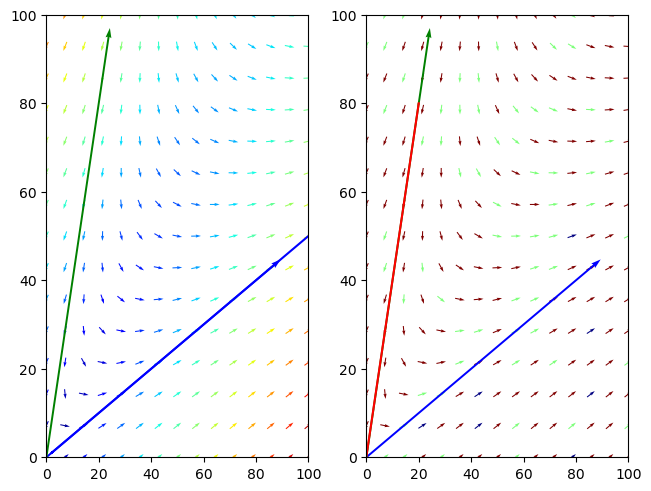

In [3]:
xy_range = [0, 100, 0, 100]
n_points = 15
A, B = gen_mesh(xy_range, n_points)
coefs = (9 / 7, -4 / 7, 8 / 7, -9 / 7)
u, v = derivatives(0, [A, B], *coefs)

_, axes = plt.subplots(1, 2, constrained_layout=1)

xy_inits = [[2, 1], [20, 80]]
vecs = [1, 10]
colors = ["b", "r"]

M = np.array([coefs[0:2], coefs[2:4]])
eigen_values, eigen_vectors = linalg.eig(M)
X, Y = eigen_vectors
origin = [0, 0]

t_spans = [[0, 10], [0, 100]]
ts = [
    np.linspace(t_spans[0][0], t_spans[0][1], 5000),
    np.linspace(t_spans[1][0], t_spans[1][1], 5000),
]

for i, (t_span, xy_init, vec, _color) in enumerate(
    zip(t_spans, xy_inits, vecs, colors)
):
    sol = integrate.solve_ivp(
        derivatives, t_span, xy_init, args=coefs, dense_output=True
    )
    Z = sol.sol(ts[i]).T
    x, y = Z[:, 0], Z[:, 1]

    x_arrows, y_arrows, time = pillar(x, y, vec)
    direction_x = np.array(x_arrows[1:]) - np.array(x_arrows[:-1])
    direction_y = np.array(y_arrows[1:]) - np.array(y_arrows[:-1])
    axes[i].quiver(
        x_arrows[:-1],
        y_arrows[:-1],
        direction_x,
        direction_y,
        scale=1000,
        lw=time[:-1],
        color=_color,
    )

    vector_field(axes[i], A, B, u, v)
    axes[i].quiver(
        origin,
        origin,
        X,
        Y,
        scale=0.01,
        scale_units="xy",
        angles="xy",
        color=["b", "g"],
    )

    axes[i].plot(x, y, color=_color)
    axes[i].set(xlim=(0, 100), ylim=(0, 100))

### Saddle

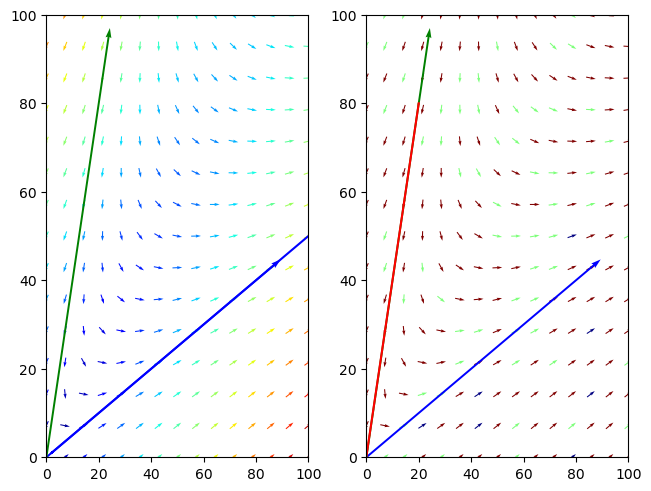

In [4]:
xy_range = [0, 100, 0, 100]
n_points = 15
A, B = gen_mesh(xy_range, n_points)
u, v = derivatives(0, [A, B], *coefs)

_, axes = plt.subplots(1, 2, constrained_layout=1)

xy_inits = [[2, 1], [20, 80]]
vecs = [1, 10]
colors = ["b", "r"]

M = np.array([coefs[0:2], coefs[2:4]])
eigen_values, eigen_vectors = linalg.eig(M)
X, Y = eigen_vectors
origin = [0, 0]

t_spans = [[0, 10], [0, 100]]
ts = [
    np.linspace(t_spans[0][0], t_spans[0][1], 5000),
    np.linspace(t_spans[1][0], t_spans[1][1], 5000),
]

for i, (t_span, xy_init, vec, _color) in enumerate(
    zip(t_spans, xy_inits, vecs, colors)
):
    sol = integrate.solve_ivp(
        derivatives, t_span, xy_init, args=coefs, dense_output=True
    )
    Z = sol.sol(ts[i]).T
    x, y = Z[:, 0], Z[:, 1]

    x_arrows, y_arrows, time = pillar(x, y, vec)
    direction_x = np.array(x_arrows[1:]) - np.array(x_arrows[:-1])
    direction_y = np.array(y_arrows[1:]) - np.array(y_arrows[:-1])
    axes[i].quiver(
        x_arrows[:-1],
        y_arrows[:-1],
        direction_x,
        direction_y,
        scale=1000,
        lw=time[:-1],
        color=_color,
    )

    vector_field(axes[i], A, B, u, v)
    axes[i].quiver(
        origin,
        origin,
        X,
        Y,
        scale=0.01,
        scale_units="xy",
        angles="xy",
        color=["b", "g"],
    )

    axes[i].plot(x, y, color=_color)
    axes[i].set(xlim=(0, 100), ylim=(0, 100))

### Spiral

In [5]:
def derivatives(X, V):
    u = V
    v = -X - (V**3 - V)
    return [u, v]

In [6]:
def euler2(xy_init, step_size, period):
    X, Y = xy_init
    x, y = [], []
    time = []
    for i in range(period):
        x.append(X)
        y.append(Y)
        X += step_size * derivatives(x[-1], y[-1])[0]
        Y += step_size * derivatives(x[-1], y[-1])[1]
        time.append(step_size * i)
    return x, y, time

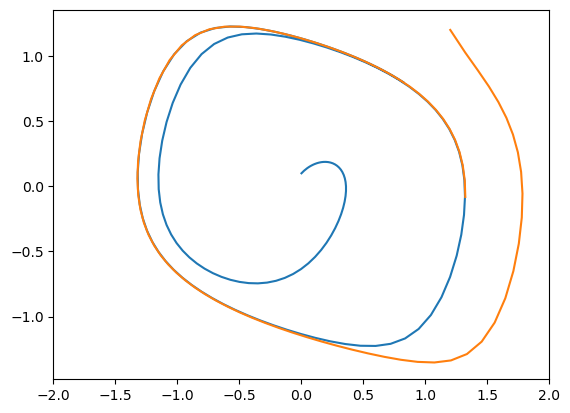

In [7]:
xy_inits = [[0, 0.1], [1.2, 1.2]]
step_sizes = [0.1, 0.1]
periods = [150, 80]

_, ax = plt.subplots()

for xy_init, step_size, period in zip(xy_inits, step_sizes, periods):
    x, y, t = euler2(xy_init, step_size, period)

    ax.plot(x, y)
    ax.set(xlim=(-2, 2))

## Orthogonalization

/Users/integzz/.conda/envs/kaggle/lib/python3.14/site-packages/scipy/integrate/_ivp/base.py:24: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


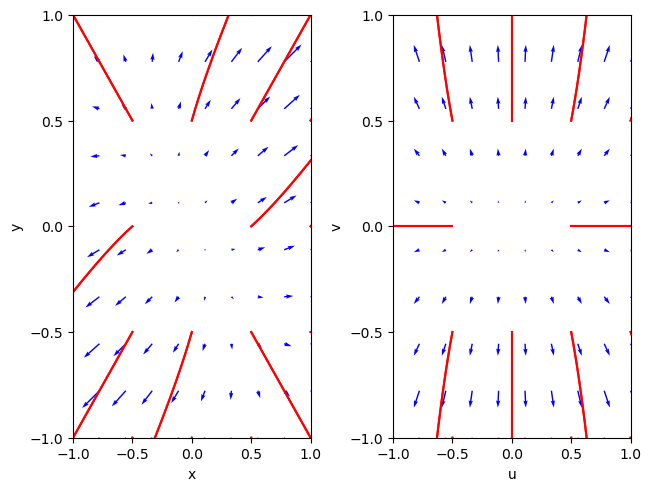

In [8]:
a, b, c, d = 2, 1, 1, 2
m = np.array([[a, b], [c, d]])
eigen = linalg.eig(m)[0]


def derivatives(t, z):
    x, y = z
    u = a * x + b * y
    v = c * x + d * y
    return [u, v]


xlabel, ylabel = ["x", "u"], ["y", "v"]
ic = np.linspace(-1, 1, 5)

t_span1 = [0, 4]
t_span2 = [-4, 0]
t1 = np.linspace(t_span1[0], t_span1[1], 1000)
t2 = np.linspace(t_span2[0], t_span2[1], 1000)

xy_range = [-1, 1, -1, 1]
n_points = 10

_, ax = plt.subplots(1, 2, constrained_layout=1)

for i in range(2):
    if i == 1:
        a, b, c, d = eigen[1], 0, 0, eigen[0]

    for init in product(ic, ic):
        sol1 = integrate.solve_ivp(derivatives, t_span1, init, dense_output=True)
        X1 = sol1.sol(t1).T
        x1, y1 = X1[:, 0], X1[:, 1]
        ax[i].plot(x1, y1, "r-")
        sol2 = integrate.solve_ivp(derivatives, t_span2, init, dense_output=True)
        X2 = sol1.sol(t1).T
        x2, y2 = X1[:, 0], X1[:, 1]
        ax[i].plot(x2, y2, "r-")

    ax[i].set(xlim=(-1, 1), ylim=(-1, 1), xlabel=xlabel[i], ylabel=ylabel[i])

    major_locator = plt.MultipleLocator(0.5)
    ax[i].xaxis.set_major_locator(major_locator)
    ax[i].yaxis.set_major_locator(major_locator)

    # 箭头位置
    X, Y = gen_mesh(xy_range, n_points)
    # X, Y = np.mgrid[-1:1:10j, -1:1:10j]
    # 箭头方向，通常为二维度组
    u, v = derivatives(t=0, z=[X, Y])
    ax[i].quiver(X, Y, u, v, color="b")


## Switch Collins

In [9]:
def collins(t, z):
    A, B = z
    u = 5 / (1 + B**4) - A
    v = 5 / (1 + A**4) - B
    return [u, v]

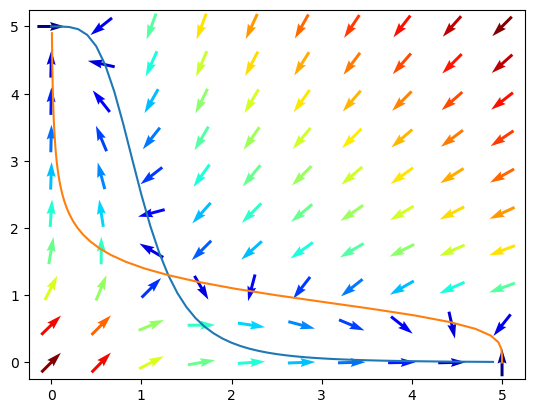

In [10]:
xy_range = [0, 5, 0, 5]
n_points = 10
A, B = gen_mesh(xy_range, n_points)
u, v = collins(t=0, z=[A, B])

_, ax = plt.subplots()

vector_field(ax, A, B, u, v)

row, col = np.arange(0, 5, 0.1), np.arange(0, 5, 0.1)
null_row, null_col = 5 / (1 + col**4), 5 / (1 + row**4)

ax.plot(row, null_col)
ax.plot(null_row, col)